In [99]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import Holt

In [100]:
model_df = pd.read_csv("../data/model-ready/ethio_modeling.csv")

model_df

,year,account_ownership,account_interp,is_observed,internet_penetration,mobile_subscriptions,agent_network,bank_branches,telebirr,mpesa,fayda
0,2014,22.0,22.000000,True,16.1,37.42,22725.0,6511.0,0,0,0
1,2015,NaN,26.333333,False,16.1,37.42,22725.0,6511.0,0,0,0
2,2016,NaN,30.666667,False,16.1,37.42,22725.0,6511.0,0,0,0
3,2017,35.0,35.000000,True,16.1,37.42,22725.0,6511.0,0,0,0
4,2018,NaN,37.750000,False,16.1,37.42,22725.0,6511.0,0,0,0
5,2019,NaN,40.500000,False,16.1,37.42,22725.0,6511.0,0,0,0
6,2020,NaN,43.250000,False,16.1,37.42,22725.0,6511.0,0,0,0
7,2021,46.0,46.000000,True,16.7,52.81,35964.0,7571.0,1,0,0
8,2022,NaN,47.000000,False,18.0,56.96,156876.0,8944.0,1,0,0
9,2023,NaN,48.000000,False,20.3,59.87,233036.0,11281.0,1,1,0


In [101]:
model_df["year"] = pd.to_datetime(
    model_df["year"], format="%Y"
)

model_df = model_df.set_index("year")


In [102]:
model_df["account_ownership"]

year
2014-01-01    22.0
2015-01-01     NaN
2016-01-01     NaN
2017-01-01    35.0
2018-01-01     NaN
2019-01-01     NaN
2020-01-01     NaN
2021-01-01    46.0
2022-01-01     NaN
2023-01-01     NaN
2024-01-01    49.0
Name: account_ownership, dtype: float64

In [103]:
y = model_df["account_interp"]

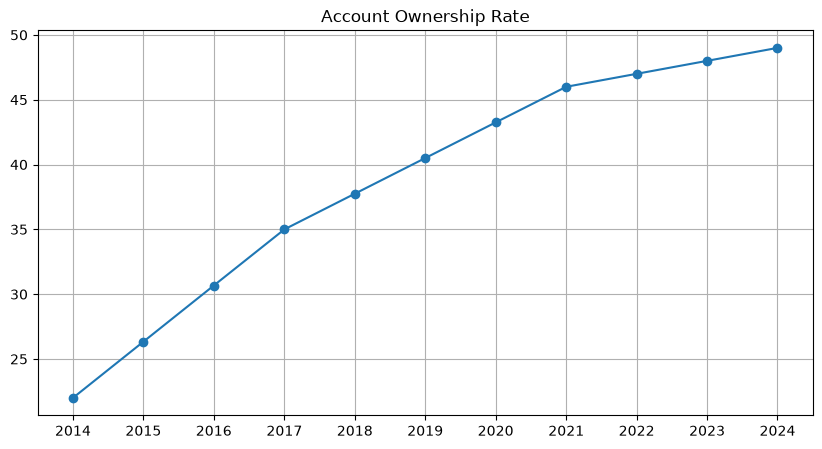

In [104]:
plt.figure(figsize=(10,5))

plt.plot(
    y,
    marker="o"
)

plt.title("Account Ownership Rate")

plt.grid(True)

plt.show()

In [105]:
holt_model = Holt(y).fit(optimized=True)

c:\Users\mijuu\Documents\mijuuhailu\financial-inclusion-forecast\.myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


In [106]:
forecast = holt_model.forecast(3)

forecast

2025-01-01    50.479761
2026-01-01    51.953014
2027-01-01    53.426267
Freq: YS-JAN, dtype: float64

In [107]:
forecast_df = pd.DataFrame({
    "forecast": forecast
})

forecast_df

,forecast
2025-01-01,50.479761
2026-01-01,51.953014
2027-01-01,53.426267


In [108]:
forecast_df["forecast"].dtype

dtype('float64')

In [109]:
forecast.index

DatetimeIndex(['2025-01-01', '2026-01-01', '2027-01-01'], dtype='datetime64[us]', freq='YS-JAN')

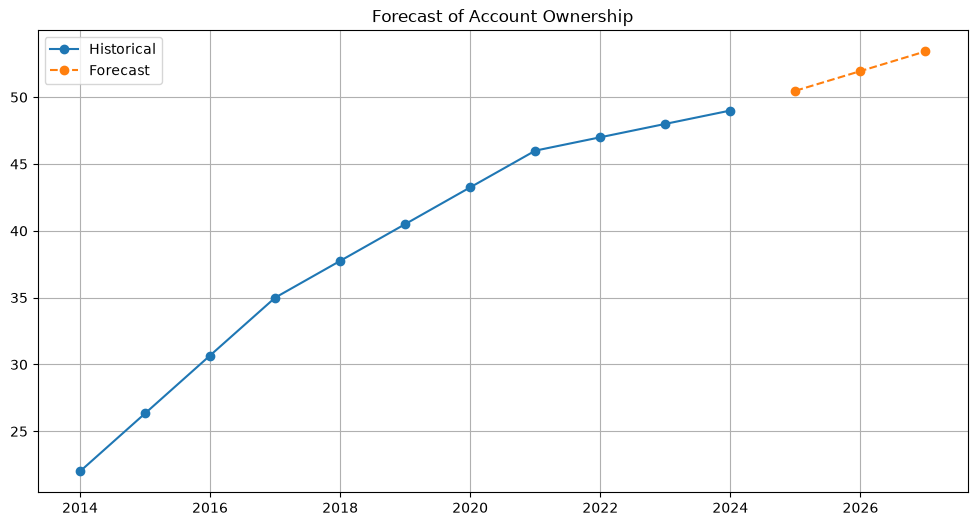

In [110]:
plt.figure(figsize=(12,6))

plt.plot(
    y,
    marker="o",
    label="Historical"
)

plt.plot(
    forecast,
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.legend()

plt.grid(True)

plt.title("Forecast of Account Ownership")

plt.show()

In [111]:
forecast_df.index = forecast_df.index.year

forecast_df

,forecast
2025,50.479761
2026,51.953014
2027,53.426267


In [112]:
forecast_df.index.name = "year"

In [119]:

forecast_df

,forecast
year,
2025,50.479761
2026,51.953014
2027,53.426267


In [122]:
forecast_df.to_csv(
    "../data/processed/account_forecast.csv",
    index=True
)

Due to the limited availability of historical Global Findex observations (2014, 2017, 2021, and 2024), a conventional train-test split would have produced an insufficient test set for meaningful evaluation. Therefore, the forecasting model was trained using all available historical observations, with interpolated annual values used to create a continuous time series. This approach prioritizes producing forecasts over estimating out-of-sample predictive accuracy and is appropriate for exploratory analysis with sparse historical data.